# M5 Competition - Item Types Analysis

This notebook explores the M5 Forecasting Competition dataset to understand the different types of items being sold across Walmart stores.

**Data sources:**
- `sales_train_evaluation.csv` — daily unit sales per item/store
- `sell_prices.csv` — weekly selling prices per item/store
- `calendar.csv` — date information and events

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR = os.path.join("..", "data")

# Load only the metadata columns from sales (skip the 1,941 daily columns for speed)
sales = pd.read_csv(
    os.path.join(DATA_DIR, "sales_train_evaluation.csv"),
    usecols=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
)
calendar = pd.read_csv(os.path.join(DATA_DIR, "calendar.csv"))
sell_prices = pd.read_csv(os.path.join(DATA_DIR, "sell_prices.csv"))

print(f"Sales rows : {len(sales):,}")
print(f"Calendar rows : {len(calendar):,}")
print(f"Sell-prices rows: {len(sell_prices):,}")

Sales rows : 30,490
Calendar rows : 1,969
Sell-prices rows: 6,841,121


## 1. Hierarchical Structure of Items

The M5 dataset organizes products in a hierarchy:

| Level | Column | Example |
|-------|--------|---------|
| Category | `cat_id` | FOODS, HOBBIES, HOUSEHOLD |
| Department | `dept_id` | FOODS_1, FOODS_2, FOODS_3 |
| Item | `item_id` | FOODS_1_001, FOODS_1_002, ... |

In [9]:
print("=== Unique counts ===")
print(f"Categories   : {sales['cat_id'].nunique()}  -> {sorted(sales['cat_id'].unique())}")
print(f"Departments  : {sales['dept_id'].nunique()}  -> {sorted(sales['dept_id'].unique())}")
print(f"Items        : {sales['item_id'].nunique()}")
print(f"Stores       : {sales['store_id'].nunique()}  -> {sorted(sales['store_id'].unique())}")
print(f"States       : {sales['state_id'].nunique()}  -> {sorted(sales['state_id'].unique())}")

=== Unique counts ===
Categories   : 3  -> ['FOODS', 'HOBBIES', 'HOUSEHOLD']
Departments  : 7  -> ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']
Items        : 3049
Stores       : 10  -> ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
States       : 3  -> ['CA', 'TX', 'WI']


## 2. Number of Items per Category

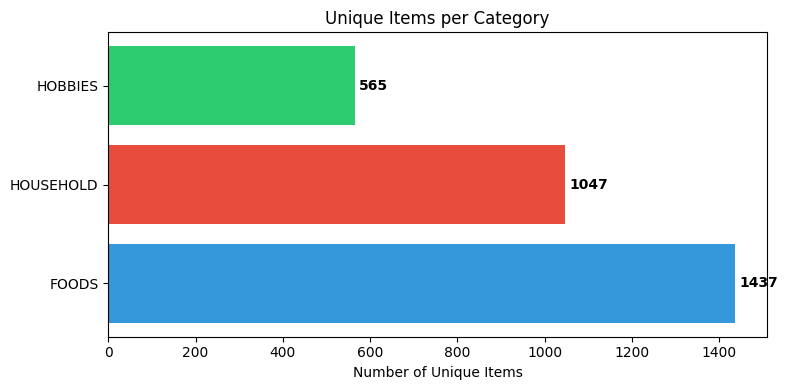

,cat_id,num_items
0,FOODS,1437
1,HOUSEHOLD,1047
2,HOBBIES,565


In [10]:
items_per_cat = sales.drop_duplicates(subset="item_id").groupby("cat_id").size().sort_values(ascending=False)
items_per_cat = items_per_cat.reset_index(name="num_items")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(items_per_cat["cat_id"], items_per_cat["num_items"], color=["#3498db", "#e74c3c", "#2ecc71"])
ax.set_xlabel("Number of Unique Items")
ax.set_title("Unique Items per Category")
for i, v in enumerate(items_per_cat["num_items"]):
    ax.text(v + 10, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

items_per_cat

## 3. Number of Items per Department

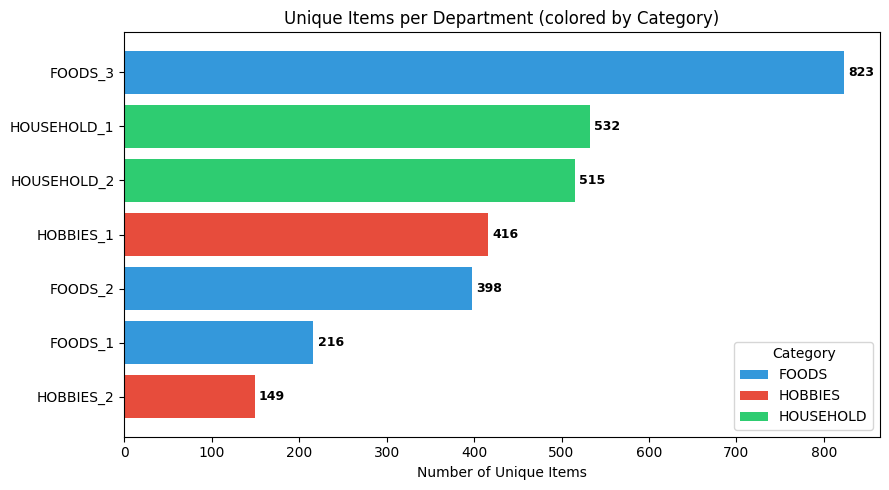

,cat_id,dept_id,num_items
4,HOBBIES,HOBBIES_2,149
0,FOODS,FOODS_1,216
1,FOODS,FOODS_2,398
3,HOBBIES,HOBBIES_1,416
6,HOUSEHOLD,HOUSEHOLD_2,515
5,HOUSEHOLD,HOUSEHOLD_1,532
2,FOODS,FOODS_3,823


In [11]:
items_per_dept = sales.drop_duplicates(subset="item_id").groupby(["cat_id", "dept_id"]).size().reset_index(name="num_items")
items_per_dept = items_per_dept.sort_values("num_items", ascending=True)

# Color-code by category
cat_colors = {"FOODS": "#3498db", "HOBBIES": "#e74c3c", "HOUSEHOLD": "#2ecc71"}
colors = items_per_dept["cat_id"].map(cat_colors)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(items_per_dept["dept_id"], items_per_dept["num_items"], color=colors)
ax.set_xlabel("Number of Unique Items")
ax.set_title("Unique Items per Department (colored by Category)")
for i, (v, dept) in enumerate(zip(items_per_dept["num_items"], items_per_dept["dept_id"])):
    ax.text(v + 5, i, str(v), va="center", fontweight="bold", fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in cat_colors.items()]
ax.legend(handles=legend_elements, title="Category", loc="lower right")

plt.tight_layout()
plt.show()

items_per_dept

## 4. Item-Store Combinations per Category & State

In [12]:
combo_table = sales.groupby(["cat_id", "state_id"]).size().unstack(fill_value=0)
combo_table.loc["TOTAL"] = combo_table.sum()
combo_table["TOTAL"] = combo_table.sum(axis=1)

print("Item-Store combinations (rows in sales_train_evaluation):")
combo_table

Item-Store combinations (rows in sales_train_evaluation):


state_id,CA,TX,WI,TOTAL
cat_id,,,,
FOODS,5748,4311,4311,14370
HOBBIES,2260,1695,1695,5650
HOUSEHOLD,4188,3141,3141,10470
TOTAL,12196,9147,9147,30490


## 5. Number of Stores per State

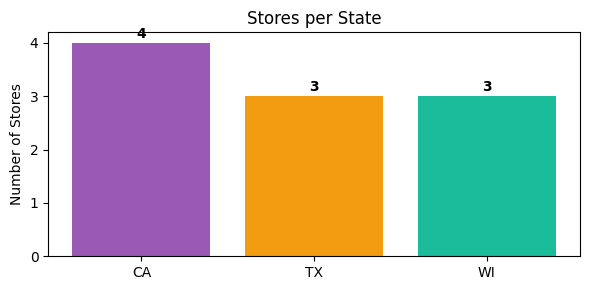

,state_id,store_id,num_stores
0,CA,"[CA_1, CA_2, CA_3, CA_4]",4
1,TX,"[TX_1, TX_2, TX_3]",3
2,WI,"[WI_1, WI_2, WI_3]",3


In [13]:
stores_per_state = sales.drop_duplicates(subset="store_id").groupby("state_id")["store_id"].apply(list).reset_index()
stores_per_state["num_stores"] = stores_per_state["store_id"].apply(len)

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(stores_per_state["state_id"], stores_per_state["num_stores"], color=["#9b59b6", "#f39c12", "#1abc9c"])
ax.set_ylabel("Number of Stores")
ax.set_title("Stores per State")
for i, v in enumerate(stores_per_state["num_stores"]):
    ax.text(i, v + 0.1, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

stores_per_state

## 6. Average Sell Price Distribution by Category

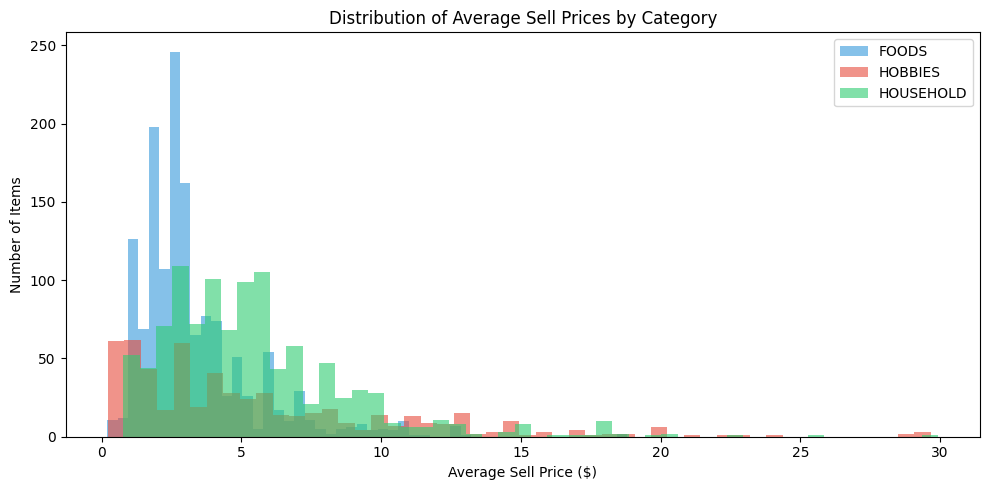

Price statistics by category:


,count,mean,std,min,25%,50%,75%,max
cat_id,,,,,,,,
FOODS,1437.0,3.29,2.13,0.20,1.98,2.73,3.93,18.80
HOBBIES,565.0,5.56,5.18,0.23,1.82,3.97,7.85,29.67
HOUSEHOLD,1047.0,5.44,3.45,0.78,2.98,4.87,6.95,29.94


In [14]:
# Derive category from item_id in sell_prices
sell_prices["cat_id"] = sell_prices["item_id"].str.rsplit("_", n=2).str[0]

avg_price = sell_prices.groupby(["item_id", "cat_id"])["sell_price"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for cat, color in cat_colors.items():
    subset = avg_price[avg_price["cat_id"] == cat]
    ax.hist(subset["sell_price"], bins=50, alpha=0.6, label=cat, color=color)

ax.set_xlabel("Average Sell Price ($)")
ax.set_ylabel("Number of Items")
ax.set_title("Distribution of Average Sell Prices by Category")
ax.legend()
plt.tight_layout()
plt.show()

print("Price statistics by category:")
avg_price.groupby("cat_id")["sell_price"].describe().round(2)

## 7. Summary Table — Items by Department and Store

In [15]:
summary = sales.groupby(["dept_id", "store_id"]).agg(
    num_items=("item_id", "nunique")
).unstack(fill_value=0)

summary.columns = summary.columns.droplevel(0)
summary["TOTAL"] = summary.sum(axis=1)
summary.loc["TOTAL"] = summary.sum()

summary

store_id,CA_1,CA_2,CA_3,CA_4,TX_1,TX_2,TX_3,WI_1,WI_2,WI_3,TOTAL
dept_id,,,,,,,,,,,
FOODS_1,216,216,216,216,216,216,216,216,216,216,2160
FOODS_2,398,398,398,398,398,398,398,398,398,398,3980
FOODS_3,823,823,823,823,823,823,823,823,823,823,8230
HOBBIES_1,416,416,416,416,416,416,416,416,416,416,4160
HOBBIES_2,149,149,149,149,149,149,149,149,149,149,1490
HOUSEHOLD_1,532,532,532,532,532,532,532,532,532,532,5320
HOUSEHOLD_2,515,515,515,515,515,515,515,515,515,515,5150
TOTAL,3049,3049,3049,3049,3049,3049,3049,3049,3049,3049,30490


## 8. Deep Dive — Items in the FOODS Category

Let's explore the different items within the FOODS category, broken down by department (FOODS_1, FOODS_2, FOODS_3).

In [16]:
# Filter FOODS items only
foods = sales[sales["cat_id"] == "FOODS"].drop_duplicates(subset="item_id")

print(f"Total unique FOODS items: {len(foods)}")
print(f"\nItems per FOODS department:")
print(foods.groupby("dept_id").size().sort_values(ascending=False).to_string())

# Show sample items from each department
print("\n" + "="*60)
for dept in sorted(foods["dept_id"].unique()):
    dept_items = foods[foods["dept_id"] == dept]["item_id"].sort_values().values
    print(f"\n{dept} ({len(dept_items)} items):")
    print(f"  First 10: {list(dept_items[:10])}")
    print(f"  Last  10: {list(dept_items[-10:])}")

Total unique FOODS items: 1437

Items per FOODS department:
dept_id
FOODS_3    823
FOODS_2    398
FOODS_1    216


FOODS_1 (216 items):
  First 10: ['FOODS_1_001', 'FOODS_1_002', 'FOODS_1_003', 'FOODS_1_004', 'FOODS_1_005', 'FOODS_1_006', 'FOODS_1_008', 'FOODS_1_009', 'FOODS_1_010', 'FOODS_1_011']
  Last  10: ['FOODS_1_210', 'FOODS_1_211', 'FOODS_1_212', 'FOODS_1_213', 'FOODS_1_214', 'FOODS_1_215', 'FOODS_1_216', 'FOODS_1_217', 'FOODS_1_218', 'FOODS_1_219']

FOODS_2 (398 items):
  First 10: ['FOODS_2_001', 'FOODS_2_002', 'FOODS_2_003', 'FOODS_2_004', 'FOODS_2_005', 'FOODS_2_006', 'FOODS_2_007', 'FOODS_2_008', 'FOODS_2_009', 'FOODS_2_010']
  Last  10: ['FOODS_2_390', 'FOODS_2_391', 'FOODS_2_392', 'FOODS_2_393', 'FOODS_2_394', 'FOODS_2_395', 'FOODS_2_396', 'FOODS_2_397', 'FOODS_2_398', 'FOODS_2_399']

FOODS_3 (823 items):
  First 10: ['FOODS_3_001', 'FOODS_3_002', 'FOODS_3_003', 'FOODS_3_004', 'FOODS_3_005', 'FOODS_3_006', 'FOODS_3_007', 'FOODS_3_008', 'FOODS_3_009', 'FOODS_3_010']
  Las

In [17]:
# Merge FOODS items with average sell prices
foods_prices = sell_prices[sell_prices["cat_id"] == "FOODS"].copy()
foods_prices["dept_id"] = foods_prices["item_id"].str.rsplit("_", n=1).str[0]

foods_avg = foods_prices.groupby(["dept_id", "item_id"]).agg(
    avg_price=("sell_price", "mean"),
    min_price=("sell_price", "min"),
    max_price=("sell_price", "max"),
    num_weeks_sold=("sell_price", "count"),
).reset_index()

# Show statistics per department
print("FOODS items — Price statistics by department:\n")
for dept in sorted(foods_avg["dept_id"].unique()):
    sub = foods_avg[foods_avg["dept_id"] == dept]
    print(f"--- {dept} ({len(sub)} items) ---")
    print(f"  Avg price range: ${sub['avg_price'].min():.2f} – ${sub['avg_price'].max():.2f}")
    print(f"  Mean avg price : ${sub['avg_price'].mean():.2f}")
    print(f"  Median avg price: ${sub['avg_price'].median():.2f}")
    print()

FOODS items — Price statistics by department:

--- FOODS_1 (216 items) ---
  Avg price range: $0.97 – $11.40
  Mean avg price : $3.33
  Median avg price: $2.51

--- FOODS_2 (398 items) ---
  Avg price range: $0.82 – $12.97
  Mean avg price : $4.15
  Median avg price: $2.97

--- FOODS_3 (823 items) ---
  Avg price range: $0.20 – $18.80
  Mean avg price : $2.87
  Median avg price: $2.52



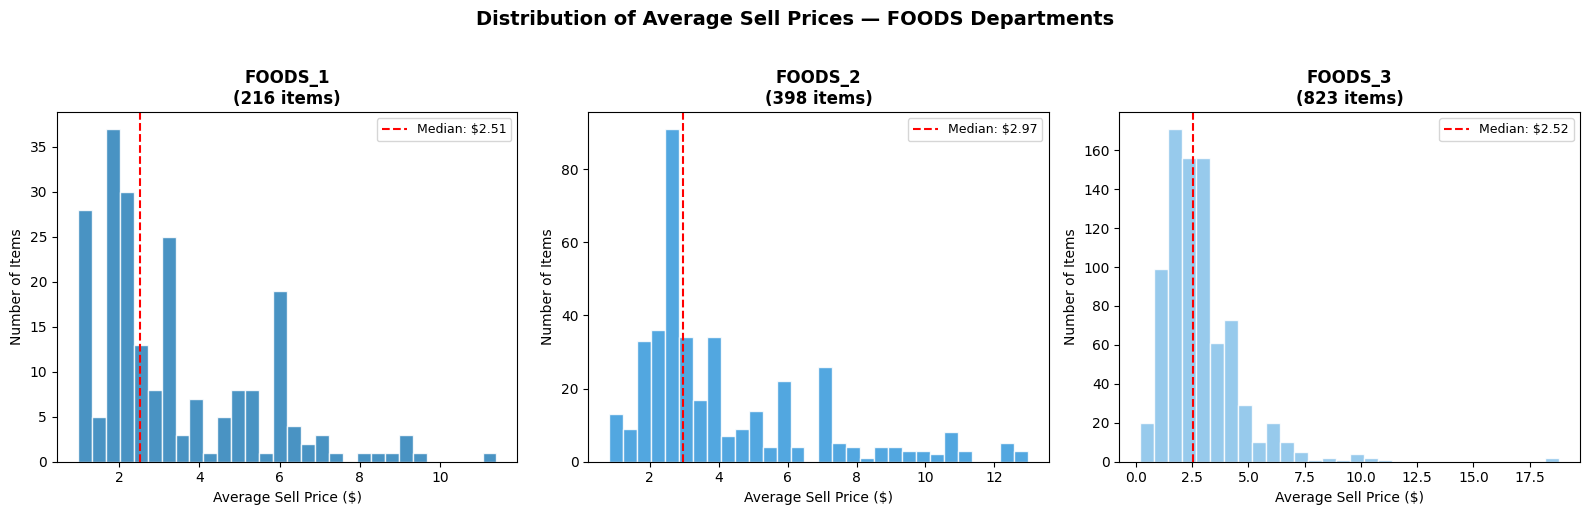

In [18]:
# Visualize FOODS item distribution by department
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

dept_colors = {"FOODS_1": "#2980b9", "FOODS_2": "#3498db", "FOODS_3": "#85c1e9"}

for ax, dept in zip(axes, sorted(foods_avg["dept_id"].unique())):
    sub = foods_avg[foods_avg["dept_id"] == dept]
    ax.hist(sub["avg_price"], bins=30, color=dept_colors[dept], edgecolor="white", alpha=0.85)
    ax.set_title(f"{dept}\n({len(sub)} items)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Average Sell Price ($)")
    ax.set_ylabel("Number of Items")
    ax.axvline(sub["avg_price"].median(), color="red", linestyle="--", linewidth=1.5, label=f"Median: ${sub['avg_price'].median():.2f}")
    ax.legend(fontsize=9)

fig.suptitle("Distribution of Average Sell Prices — FOODS Departments", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

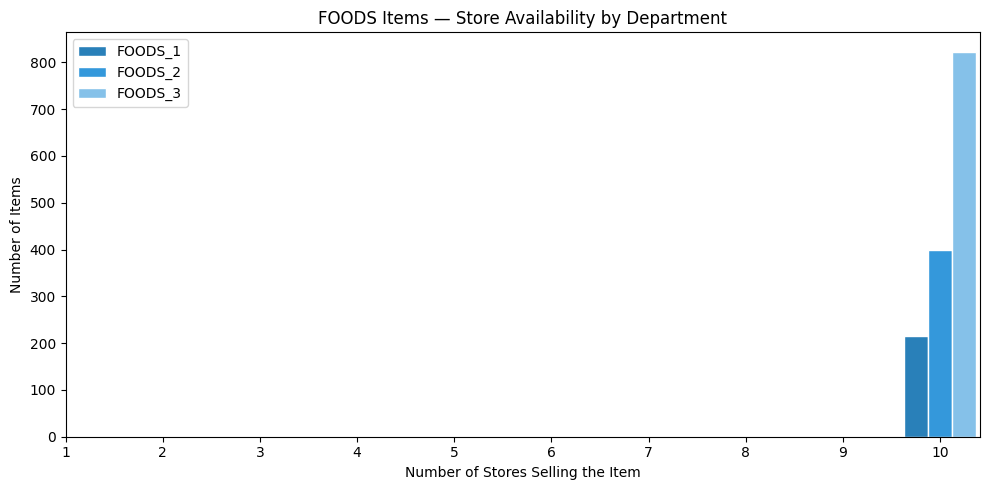

FOODS items per department and number of stores they appear in:


num_stores,10,Total
dept_id,,
FOODS_1,216,216
FOODS_2,398,398
FOODS_3,823,823
Total,1437,1437


In [19]:
# FOODS items availability across stores
foods_store = sales[sales["cat_id"] == "FOODS"].groupby(["dept_id", "item_id"])["store_id"].nunique().reset_index()
foods_store.columns = ["dept_id", "item_id", "num_stores"]

fig, ax = plt.subplots(figsize=(10, 5))
for dept, color in dept_colors.items():
    sub = foods_store[foods_store["dept_id"] == dept]
    counts = sub["num_stores"].value_counts().sort_index()
    ax.bar(counts.index + (list(dept_colors.keys()).index(dept) - 1) * 0.25, counts.values, 
           width=0.25, label=dept, color=color, edgecolor="white")

ax.set_xlabel("Number of Stores Selling the Item")
ax.set_ylabel("Number of Items")
ax.set_title("FOODS Items — Store Availability by Department")
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.show()

# Summary table
print("FOODS items per department and number of stores they appear in:")
pd.crosstab(foods_store["dept_id"], foods_store["num_stores"], margins=True, margins_name="Total")

## 9. Demand Over Time — Sample of FOODS Items

For each FOODS department (FOODS_1, FOODS_2, FOODS_3) we randomly sample 10 items and plot their daily unit sales over the full time horizon.

In [20]:
import numpy as np

# ── Load full sales data (all daily columns) for FOODS items only ──
# We read the full file but filter to FOODS rows right away
sales_full = pd.read_csv(os.path.join(DATA_DIR, "sales_train_evaluation.csv"))
sales_foods = sales_full[sales_full["cat_id"] == "FOODS"].copy()

# Build a date index from calendar
day_cols = [c for c in sales_foods.columns if c.startswith("d_")]
dates = calendar.set_index("d")["date"].to_dict()  # d_1 -> "2011-01-29"
date_index = pd.to_datetime([dates[d] for d in day_cols])

print(f"FOODS rows loaded: {len(sales_foods):,}")
print(f"Daily columns: {len(day_cols)} (from {day_cols[0]} to {day_cols[-1]})")
print(f"Date range: {date_index.min().date()} → {date_index.max().date()}")

FOODS rows loaded: 14,370
Daily columns: 1941 (from d_1 to d_1941)
Date range: 2011-01-29 → 2016-05-22


In [21]:
# ── Aggregate daily demand per item (sum across all 10 stores) ──
foods_demand = sales_foods.groupby(["dept_id", "item_id"])[day_cols].sum()

# ── Filter: remove items with >10 consecutive zero-demand days after 2015 ──
post_2015_mask = date_index >= "2015-01-01"
post_2015_cols = [c for c, m in zip(day_cols, post_2015_mask) if m]

def max_consecutive_zeros(row):
    """Return the longest run of consecutive zeros in the row."""
    vals = row.values
    max_run = 0
    current_run = 0
    for v in vals:
        if v == 0:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 0
    return max_run

zero_runs = foods_demand[post_2015_cols].apply(max_consecutive_zeros, axis=1)
valid_mask = zero_runs <= 10
foods_demand_filtered = foods_demand[valid_mask]

print(f"Items before filter: {len(foods_demand)}")
print(f"Items after filter (<=10 consecutive zero days post-2015): {len(foods_demand_filtered)}")
print(f"Removed: {len(foods_demand) - len(foods_demand_filtered)}")

# ── Sample 10 items from each FOODS department (from filtered set) ──
np.random.seed(42)
sampled_items = {}
for dept in sorted(foods_demand_filtered.index.get_level_values("dept_id").unique()):
    dept_items = foods_demand_filtered.loc[dept].index.tolist()
    n = min(10, len(dept_items))
    sampled = np.random.choice(dept_items, size=n, replace=False)
    sampled_items[dept] = sorted(sampled)
    print(f"{dept}: {len(dept_items)} valid items, sampled {n} → {list(sampled)}")

Items before filter: 1437
Items after filter (<=10 consecutive zero days post-2015): 954
Removed: 483
FOODS_1: 153 valid items, sampled 10 → [np.str_('FOODS_1_122'), np.str_('FOODS_1_127'), np.str_('FOODS_1_142'), np.str_('FOODS_1_164'), np.str_('FOODS_1_045'), np.str_('FOODS_1_163'), np.str_('FOODS_1_112'), np.str_('FOODS_1_118'), np.str_('FOODS_1_027'), np.str_('FOODS_1_023')]
FOODS_2: 248 valid items, sampled 10 → [np.str_('FOODS_2_010'), np.str_('FOODS_2_318'), np.str_('FOODS_2_081'), np.str_('FOODS_2_096'), np.str_('FOODS_2_101'), np.str_('FOODS_2_068'), np.str_('FOODS_2_268'), np.str_('FOODS_2_248'), np.str_('FOODS_2_343'), np.str_('FOODS_2_157')]
FOODS_3: 553 valid items, sampled 10 → [np.str_('FOODS_3_377'), np.str_('FOODS_3_704'), np.str_('FOODS_3_253'), np.str_('FOODS_3_611'), np.str_('FOODS_3_104'), np.str_('FOODS_3_211'), np.str_('FOODS_3_701'), np.str_('FOODS_3_687'), np.str_('FOODS_3_135'), np.str_('FOODS_3_463')]


Plotting window: 2016-04-22 → 2016-05-22 (31 days)


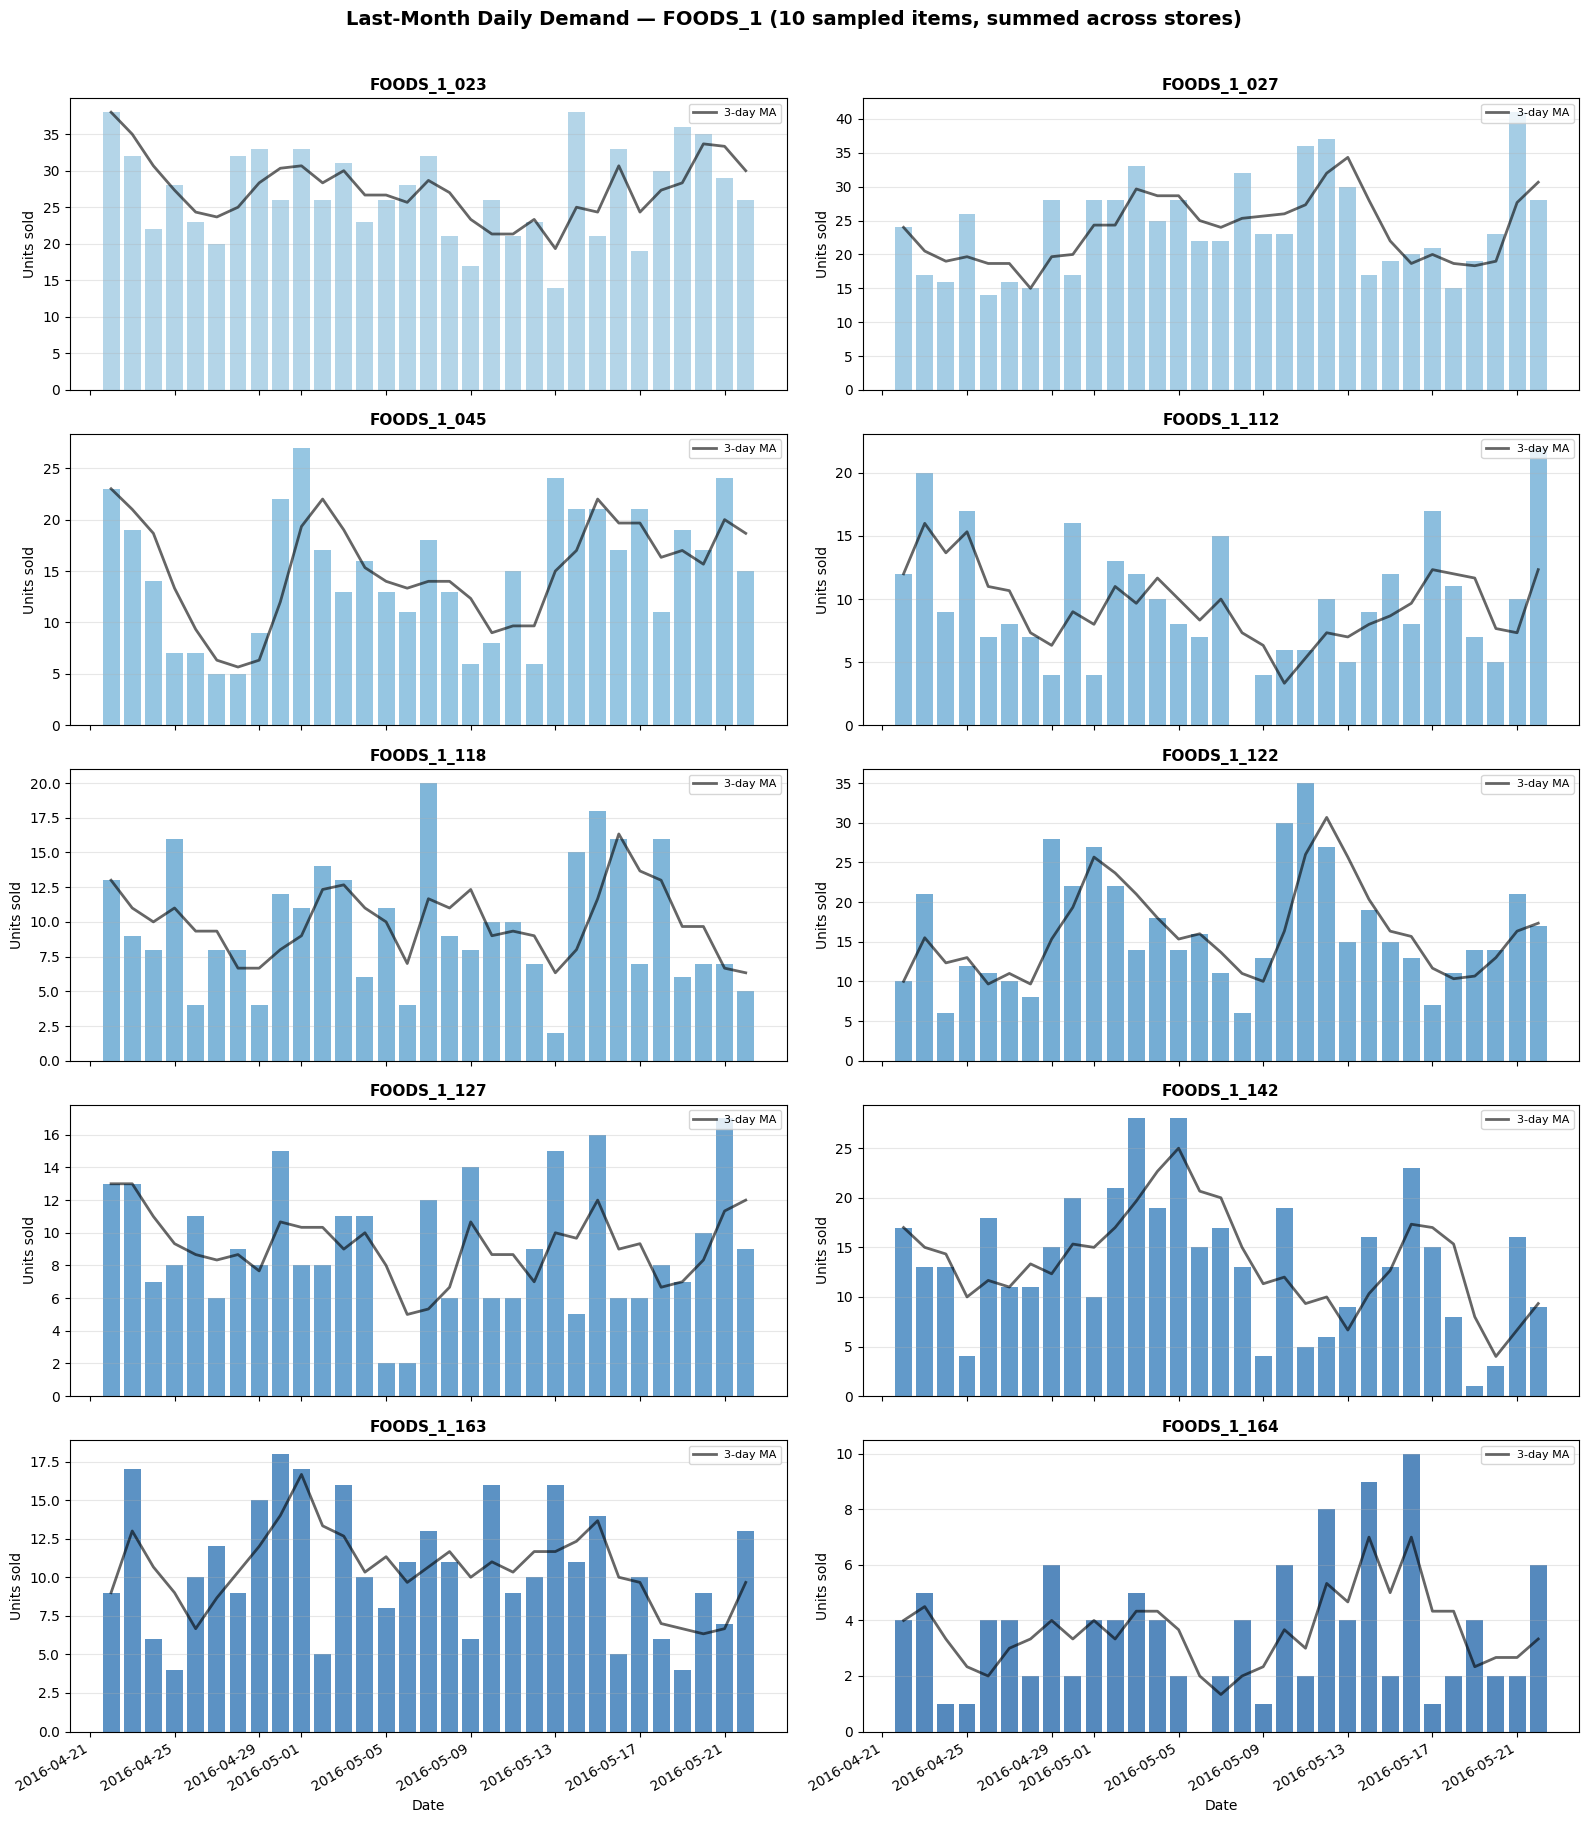

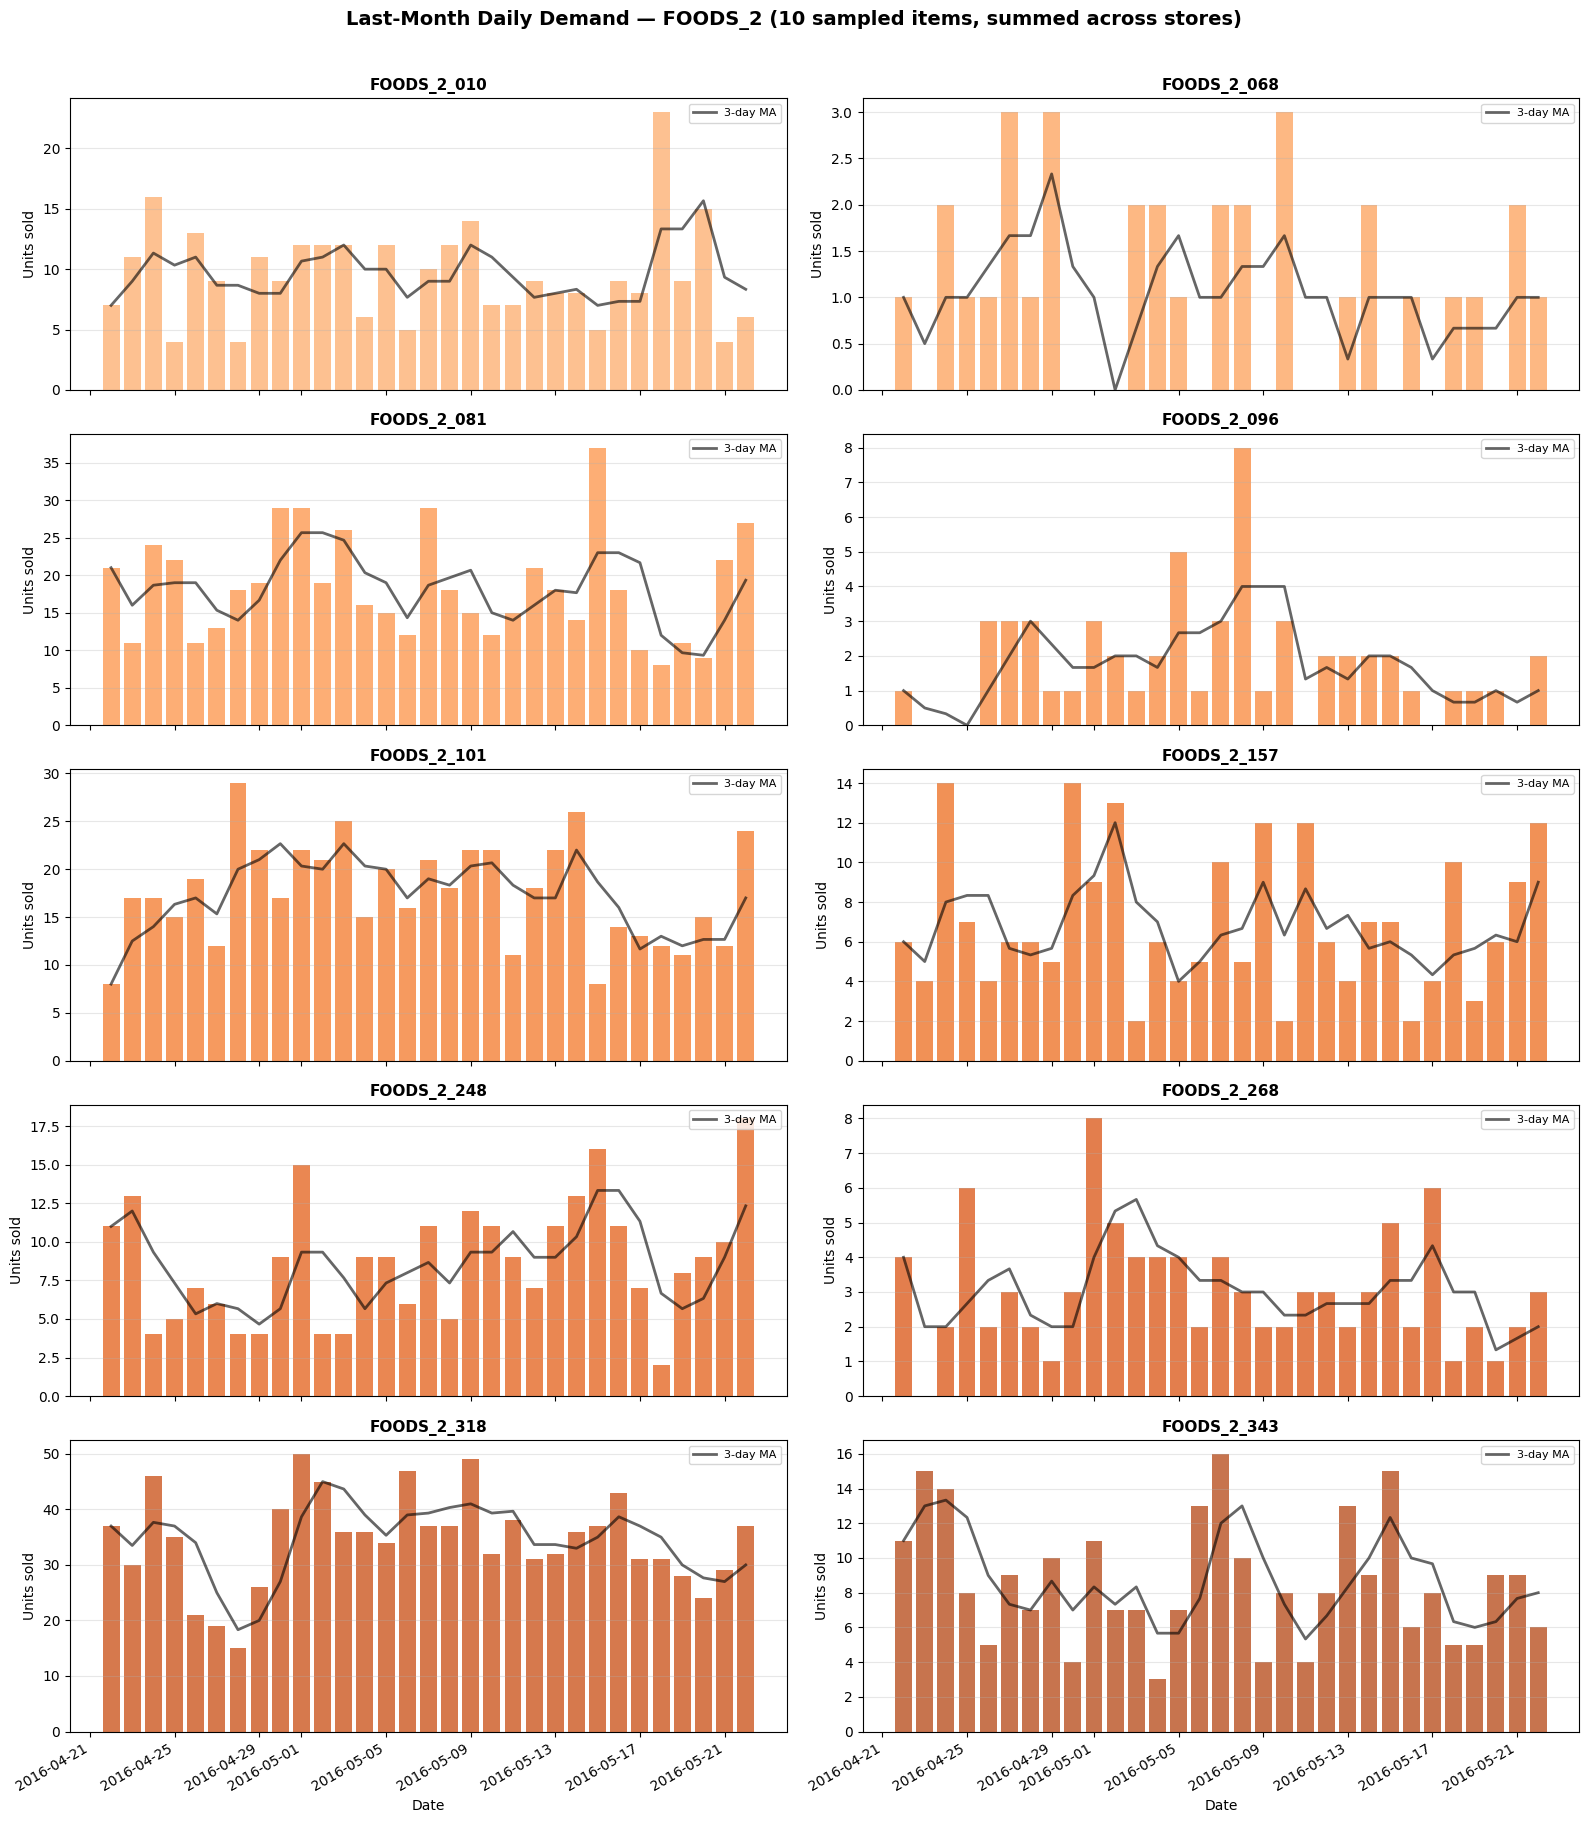

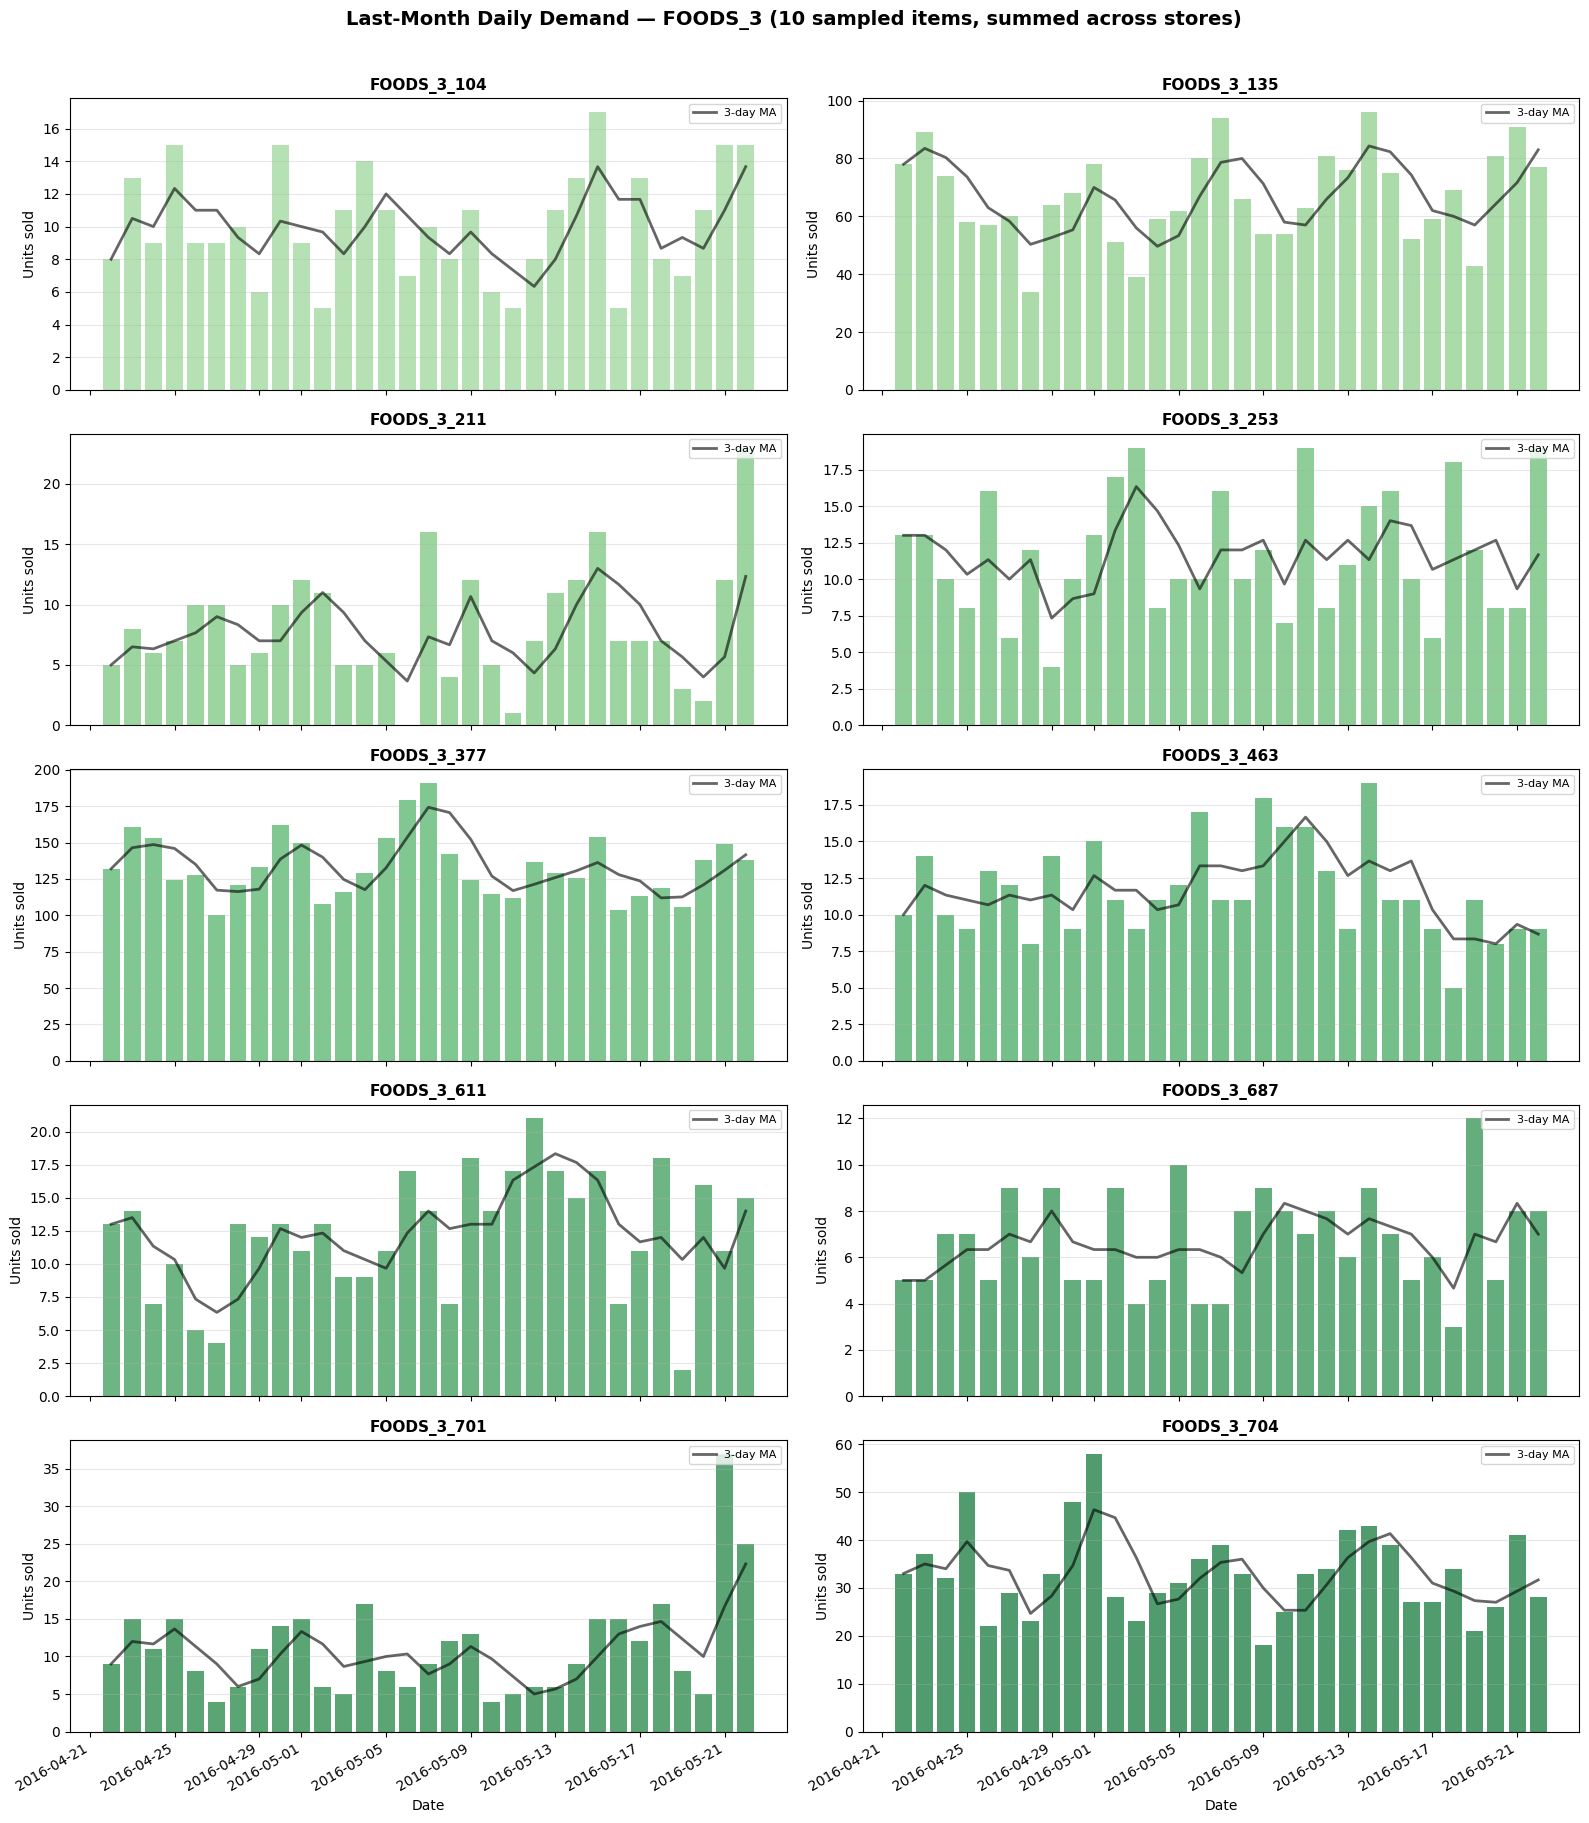

In [22]:
# ── Plot LAST MONTH of demand for each FOODS department ──
# Determine last-month window
last_date = date_index.max()
first_date_last_month = last_date - pd.Timedelta(days=30)
last_month_mask = date_index >= first_date_last_month
last_month_cols = [c for c, m in zip(day_cols, last_month_mask) if m]
last_month_dates = date_index[last_month_mask]

print(f"Plotting window: {last_month_dates.min().date()} → {last_month_dates.max().date()} ({len(last_month_cols)} days)")

dept_colors_map = {
    "FOODS_1": plt.cm.Blues,
    "FOODS_2": plt.cm.Oranges,
    "FOODS_3": plt.cm.Greens,
}

for dept, items in sampled_items.items():
    fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=True)
    fig.suptitle(f"Last-Month Daily Demand — {dept} (10 sampled items, summed across stores)",
                 fontsize=14, fontweight="bold", y=1.01)
    cmap = dept_colors_map[dept]

    for idx, (ax, item_id) in enumerate(zip(axes.flat, items)):
        ts = foods_demand_filtered.loc[(dept, item_id), last_month_cols].values.astype(float)

        color = cmap(0.4 + 0.5 * idx / len(items))
        ax.bar(last_month_dates, ts, color=color, alpha=0.7, width=0.8)
        # 3-day rolling mean
        ts_smooth = pd.Series(ts).rolling(window=3, min_periods=1).mean()
        ax.plot(last_month_dates, ts_smooth, linewidth=2, color="black", alpha=0.6, label="3-day MA")
        ax.set_title(item_id, fontsize=11, fontweight="bold")
        ax.set_ylabel("Units sold")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    axes[-1, 0].set_xlabel("Date")
    axes[-1, 1].set_xlabel("Date")
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()

## 10. Extract Daily Seasonality Profiles & Cluster into 3 Patterns

**Approach:**
1. Take the last 30 days of real sales data (matching the `setting_1.json` time horizon)
2. Group into 10 periods of 3 days each (matching the 10-period structure)
3. For each item, compute average demand per period and normalize to seasonal factors (centered ~1.0)
4. Use K-Means (k=3) to find the 3 most common daily seasonality shapes
5. Output ready-to-use `demand_distribution` JSON blocks with 10-period seasonal factors

In [23]:
# ── Step 1: Take the last 30 days and group into 10 periods of 3 days ──
# This matches the setting: time_horizon=30, 10 seasonal_factor entries

last_30_mask = date_index >= (date_index.max() - pd.Timedelta(days=29))
last_30_cols = [c for c, m in zip(day_cols, last_30_mask) if m]
last_30_dates = date_index[last_30_mask]

print(f"Last 30 days: {last_30_dates.min().date()} → {last_30_dates.max().date()} ({len(last_30_cols)} days)")

# Group into 10 periods of 3 days each
n_periods = 10
days_per_period = len(last_30_cols) // n_periods

period_demand = {}
for p in range(n_periods):
    start = p * days_per_period
    end = start + days_per_period
    period_cols = last_30_cols[start:end]
    # Average daily demand in this 3-day period
    period_demand[f"P{p+1}"] = foods_demand_filtered[period_cols].mean(axis=1)

period_df = pd.DataFrame(period_demand)  # shape: (n_items, 10)

print(f"\nPeriod demand matrix: {period_df.shape}")
print(f"Days per period: {days_per_period}")
print(period_df.head().round(2))

Last 30 days: 2016-04-23 → 2016-05-22 (30 days)

Period demand matrix: (954, 10)
Days per period: 3
                        P1     P2     P3     P4     P5     P6     P7     P8  \
dept_id item_id                                                               
FOODS_1 FOODS_1_001   8.67   4.33   7.00   4.67   5.67   4.33   5.00   6.67   
        FOODS_1_002   4.33   3.67   4.67   4.67   3.67   3.33   6.00   5.67   
        FOODS_1_003   7.67   7.67   4.33   4.67   9.00   3.67   6.67   8.33   
        FOODS_1_005  20.33  16.67  22.00  14.67  25.00  16.00  15.33  16.67   
        FOODS_1_006   9.67  12.67   8.67  14.33   8.67   6.67  14.67  13.67   

                        P9    P10  
dept_id item_id                    
FOODS_1 FOODS_1_001   6.33   7.00  
        FOODS_1_002   3.67   5.33  
        FOODS_1_003   7.67   7.00  
        FOODS_1_005  17.00  20.33  
        FOODS_1_006  11.33   8.33  


In [ ]:
# ── Step 2: Normalize each item's 10-period profile to seasonal factors ──
# seasonal_factor = period_demand / overall_mean → centered around 1.0
row_means = period_df.mean(axis=1)

# Drop items with zero mean
seasonal_profiles = period_df[row_means > 0].div(row_means[row_means > 0], axis=0)

print(f"Seasonal profiles: {seasonal_profiles.shape}")
print(f"\nExample profiles (first 5 items):")
print(seasonal_profiles.head().round(3))
print(f"\nGlobal mean of all factors (should be ~1.0): {seasonal_profiles.values.mean():.4f}")

Seasonal profiles: (954, 12)

Example profiles (first 5 items):
                     month_01  month_02  month_03  month_04  month_05  \
dept_id item_id                                                         
FOODS_1 FOODS_1_001     0.826     1.199     1.046     1.044     1.132   
        FOODS_1_002     0.915     0.999     0.987     1.090     1.086   
        FOODS_1_003     0.892     0.934     1.055     0.997     1.026   
        FOODS_1_005     1.166     1.391     1.129     0.868     0.519   
        FOODS_1_006     0.772     1.324     1.000     1.044     1.083   

                     month_06  month_07  month_08  month_09  month_10  \
dept_id item_id                                                         
FOODS_1 FOODS_1_001     1.119     1.044     0.940     0.939     0.814   
        FOODS_1_002     1.047     0.919     1.047     1.030     0.996   
        FOODS_1_003     1.107     1.015     0.999     1.063     1.051   
        FOODS_1_005     0.202     0.193     0.799     1.569

In [ ]:
# ── Step 3: K-Means clustering (k=3) ──
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20, max_iter=500)
clusters = kmeans.fit_predict(seasonal_profiles.values)

seasonal_profiles_with_cluster = seasonal_profiles.copy()
seasonal_profiles_with_cluster["cluster"] = clusters

# Count items per cluster
print("Items per cluster:")
print(pd.Series(clusters).value_counts().sort_index())

# Cluster centroids = the 3 canonical daily seasonal patterns (10 periods)
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[f"P{p+1}" for p in range(n_periods)],
    index=["Cluster_0", "Cluster_1", "Cluster_2"],
)
print("\nCluster centroids (10-period seasonal factors):")
print(centroids.round(3))

Items per cluster:
0    368
1    414
2    172
Name: count, dtype: int64

Cluster centroids (seasonal factors):
           month_01  month_02  month_03  month_04  month_05  month_06  \
Cluster_0     1.110     1.032     0.981     0.951     0.905     0.830   
Cluster_1     0.929     0.971     0.992     1.025     1.063     1.101   
Cluster_2     1.159     1.235     1.234     1.203     1.081     0.904   

           month_07  month_08  month_09  month_10  month_11  month_12  
Cluster_0     0.852     0.936     1.030     1.103     1.130     1.138  
Cluster_1     1.074     1.081     1.019     0.975     0.885     0.885  
Cluster_2     0.831     0.814     0.832     0.886     0.897     0.922  


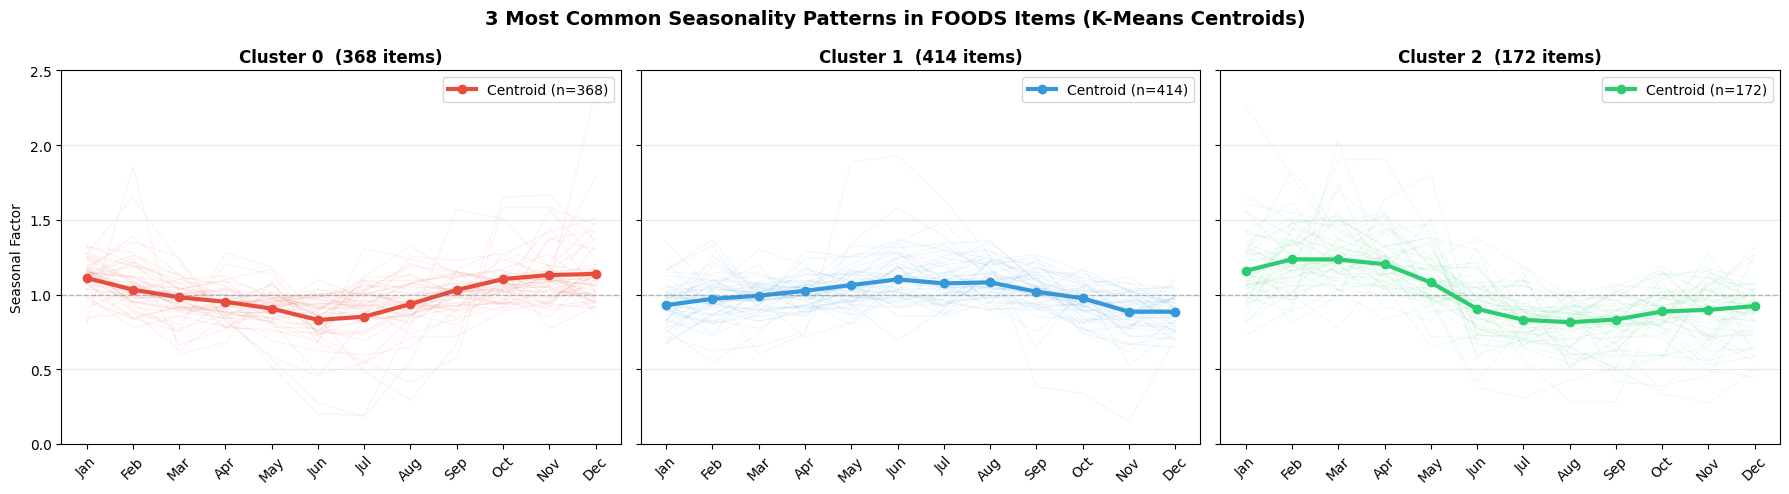

In [ ]:
# ── Step 4: Visualize the 3 daily seasonal patterns ──
period_labels = [f"P{p+1}" for p in range(n_periods)]
cluster_colors = {0: "#e74c3c", 1: "#3498db", 2: "#2ecc71"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("3 Most Common Daily Seasonality Patterns (K-Means on last 30 days, 10 periods of 3 days)",
             fontsize=13, fontweight="bold")

for i, ax in enumerate(axes):
    profile = centroids.iloc[i].values
    n_items = (clusters == i).sum()

    # Plot individual items in this cluster (faded)
    cluster_items = seasonal_profiles_with_cluster[
        seasonal_profiles_with_cluster["cluster"] == i
    ].drop(columns="cluster")
    for _, row in cluster_items.sample(min(50, len(cluster_items)), random_state=42).iterrows():
        ax.plot(range(n_periods), row.values, color=cluster_colors[i], alpha=0.08, linewidth=0.8)

    # Plot centroid (bold)
    ax.plot(range(n_periods), profile, color=cluster_colors[i], linewidth=3, marker="o",
            markersize=6, label=f"Centroid (n={n_items})")
    ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, linewidth=1)
    ax.set_xticks(range(n_periods))
    ax.set_xticklabels(period_labels)
    ax.set_ylabel("Seasonal Factor" if i == 0 else "")
    ax.set_xlabel("Period (3 days each)")
    ax.set_title(f"Cluster {i}  ({n_items} items)", fontweight="bold")
    ax.legend(loc="upper right")
    ax.set_ylim(0, 2.5)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Step 5: Per-cluster demand statistics (mu, sigma) ──
item_stats = pd.DataFrame({
    "cluster": clusters,
    "mean_daily_demand": row_means[seasonal_profiles.index].values,
    "std_across_periods": period_df.loc[seasonal_profiles.index].std(axis=1).values,
})

print("Per-cluster demand statistics:")
cluster_stats = item_stats.groupby("cluster").agg(
    n_items=("mean_daily_demand", "count"),
    avg_mu=("mean_daily_demand", "mean"),
    median_mu=("mean_daily_demand", "median"),
    avg_sigma=("std_across_periods", "mean"),
    median_sigma=("std_across_periods", "median"),
).round(2)
print(cluster_stats)

Per-cluster demand statistics:
         n_items  avg_mu  median_mu  avg_sigma  median_sigma
cluster                                                     
0            368   15.73       8.44       2.62          1.19
1            414   22.53      10.45       2.95          1.26
2            172    8.43       5.22       1.65          1.03


## 11. Generate `setting_1.json`-compatible demand parameters

Use the 3 cluster centroids directly as 10-period daily `seasonal_factor` vectors (already aligned with the setting format) and output 3 ready-to-use `demand_distribution` JSON blocks.

In [ ]:
import json

# Base demand levels for 4 items (same as your original setting_1.json)
mu_values = [5.0, 4.0, 6.0, 3.0]
sigma_values = [1.0, 1.0, 1.0, 1.5]

print("=" * 70)
print("ALL 3 SEASONAL SCENARIOS for setting_1.json")
print("=" * 70)

scenarios = {}
for i in range(3):
    profile_10 = list(np.round(centroids.iloc[i].values, 2))
    n = (clusters == i).sum()
    stats = cluster_stats.loc[i]

    scenario = {
        "name": "normal",
        "mu": [[mu] * 10 for mu in mu_values],
        "sigma": [[sig] * 10 for sig in sigma_values],
        "seasonal_factor": profile_10,
    }
    scenarios[i] = scenario

    print(f"\n{'─' * 70}")
    print(f"SCENARIO {i+1} — Cluster {i} ({n} items, "
          f"median μ={stats['median_mu']:.1f}, median σ={stats['median_sigma']:.1f})")
    print(f"  10-period factors: {profile_10}")
    print(f"{'─' * 70}")
    print(json.dumps(scenario, indent=4))

ALL 3 SEASONAL SCENARIOS for setting_1.json

──────────────────────────────────────────────────────────────────────
SCENARIO 1 — Cluster 0 (368 items, median μ=8.4, median σ=1.2)
  12-month factors: [np.float64(1.11), np.float64(1.03), np.float64(0.98), np.float64(0.95), np.float64(0.91), np.float64(0.83), np.float64(0.85), np.float64(0.94), np.float64(1.03), np.float64(1.1), np.float64(1.13), np.float64(1.14)]
  10-period factors: [np.float64(1.11), np.float64(1.02), np.float64(0.97), np.float64(0.92), np.float64(0.84), np.float64(0.86), np.float64(0.97), np.float64(1.07), np.float64(1.12), np.float64(1.14)]
──────────────────────────────────────────────────────────────────────
{
    "name": "normal",
    "mu": [
        [
            5.0,
            5.0,
            5.0,
            5.0,
            5.0,
            5.0,
            5.0,
            5.0,
            5.0,
            5.0
        ],
        [
            4.0,
            4.0,
            4.0,
            4.0,
        

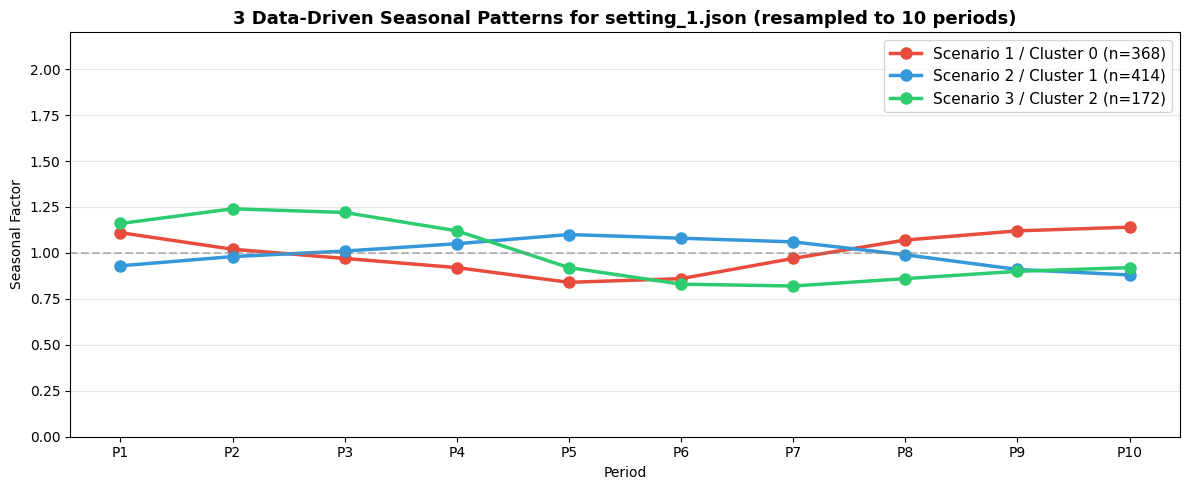

In [ ]:
# ── Final comparison plot: all 3 patterns on 10-period scale ──
fig, ax = plt.subplots(figsize=(12, 5))
period_labels = [f"P{p+1}" for p in range(10)]

for i in range(3):
    profile_10 = scenarios[i]["seasonal_factor"]
    n = (clusters == i).sum()
    ax.plot(range(10), profile_10, marker="o", linewidth=2.5, markersize=8,
            color=cluster_colors[i], label=f"Scenario {i+1} / Cluster {i} (n={n})")

ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_xticks(range(10))
ax.set_xticklabels(period_labels)
ax.set_ylabel("Seasonal Factor")
ax.set_xlabel("Period (3 days each)")
ax.set_title("3 Data-Driven Daily Seasonal Patterns for setting_1.json (10 periods from last 30 days)",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 2.2)
plt.tight_layout()
plt.show()